# Population-Level Statistics

Aggregate per-light-curve statistics across all candidates that passed through
the malca pipeline cluster stage, broken down **per magnitude bin**.

Data comes from the pre-computed `stats_*` columns in each run's
`results/lc_events_enriched.parquet`.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import json as _json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sp_stats

# ── pretty defaults ──
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

BIN_PALETTE = {
    '12–12.5': '#1b9e77',
    '12.5–13': '#d95f02',
    '13–13.5': '#7570b3',
    '13.5–14': '#e7298a',
    '14–14.5': '#66a61e',
    '14.5–15': '#e6ab02',
}
BIN_ORDER = list(BIN_PALETTE.keys())

def ordered_mag_bins(values):
    present = {str(v) for v in values if pd.notna(v)}
    return [label for label in BIN_ORDER if label in present]


def palette_for_bins(values):
    labels = ordered_mag_bins(values)
    return {label: BIN_PALETTE[label] for label in labels}


In [2]:
# ── configure run directories ────────────────────────────────────
RUN_ROOT_CANDIDATES = [Path('../../output/runs'), Path('output/runs')]
RUNS_ROOT = next((path for path in RUN_ROOT_CANDIDATES if path.exists()), RUN_ROOT_CANDIDATES[0])
print(f'Using run root: {RUNS_ROOT.resolve()}')

RUN_PATTERNS = [
    ('12_12.5', '12–12.5'),
    ('12.5_13', '12.5–13'),
    ('13_13.5', '13–13.5'),
    ('13.5_14', '13.5–14'),
    ('14_14.5', '14–14.5'),
    ('14.5_15', '14.5–15'),
]

# ── load & tag ───────────────────────────────────────────────────
frames = []
for token, label in RUN_PATTERNS:
    matches = sorted(RUNS_ROOT.glob(f'*{token}*/results/lc_events_enriched.parquet'))
    if not matches:
        print(f'⚠  no enriched parquet found for {label} under {RUNS_ROOT}')
        continue

    p = max(matches, key=lambda candidate: candidate.stat().st_mtime)
    if len(matches) > 1:
        print(f'ℹ  {label:10s}  using newest match: {p.parent.parent.name}')

    df = pd.read_parquet(p).copy()
    df['mag_bin'] = label
    df['run_name'] = p.parent.parent.name
    df['candidate_file'] = str(p)
    frames.append(df)
    print(f'✓  {label:10s}  →  {len(df):>6,} candidates  ({p.parent.parent.name})')

if not frames:
    searched = ', '.join(token for token, _ in RUN_PATTERNS)
    raise FileNotFoundError(
        f'No lc_events_enriched.parquet files found under {RUNS_ROOT} for patterns: {searched}'
    )

df_all = pd.concat(frames, ignore_index=True)
print(f'\nTotal candidates: {len(df_all):,}')


Using run root: /home/calder/code/malca/output/runs
ℹ  12–12.5     using newest match: output_bundle_12_12.5_home_bundle_12_12.5
✓  12–12.5     →   4,069 candidates  (output_bundle_12_12.5_home_bundle_12_12.5)
ℹ  12.5–13     using newest match: output_bundle_12.5_13_home_bundle_12.5_13
✓  12.5–13     →   6,074 candidates  (output_bundle_12.5_13_home_bundle_12.5_13)
ℹ  13–13.5     using newest match: output_bundle_13_13.5_bundle_13_13.5
✓  13–13.5     →   9,014 candidates  (output_bundle_13_13.5_bundle_13_13.5)
ℹ  13.5–14     using newest match: output_bundle_13.5_14_bundle_13.5_14
✓  13.5–14     →  12,506 candidates  (output_bundle_13.5_14_bundle_13.5_14)
✓  14–14.5     →  17,163 candidates  (output_bundle_14_14.5_bundle_14_14.5)
ℹ  14.5–15     using newest match: output_bundle_14.5_15_bundle_14.5_15
✓  14.5–15     →       5 candidates  (output_bundle_14.5_15_bundle_14.5_15)

Total candidates: 48,831


In [3]:
# ── identify stats columns ───────────────────────────────────────
STATS_COLS = sorted([c for c in df_all.columns if c.startswith('stats_')])

# Exclude columns that are all-NaN (e.g. Lomb-Scargle if not computed)
STATS_COLS = [c for c in STATS_COLS if df_all[c].notna().any()]

print(f'{len(STATS_COLS)} usable stats columns')
for c in STATS_COLS:
    print(f'  {c}')

71 usable stats columns
  stats_amplitude
  stats_anderson_darling
  stats_autocor_length
  stats_beyond_1_std
  stats_cadence_mean_dt_days
  stats_cadence_median_dt_days
  stats_cadence_p05_dt_days
  stats_cadence_p95_dt_days
  stats_clipped_mean_mag_3sigma_about_median
  stats_clipped_std_mag_3sigma_about_median
  stats_con
  stats_delta_mag_fid
  stats_duty_cycle_fraction
  stats_error_and_snr_stats_error_mean
  stats_error_and_snr_stats_error_median
  stats_error_and_snr_stats_error_p05
  stats_error_and_snr_stats_error_p95
  stats_error_and_snr_stats_snr_median
  stats_error_and_snr_stats_snr_p05
  stats_error_and_snr_stats_snr_p95
  stats_excess_var
  stats_file_points_kept_after_filter
  stats_file_points_total
  stats_first_mag
  stats_gp_drw_sigma
  stats_gp_drw_tau
  stats_gskew
  stats_iar_phi
  stats_jd_end
  stats_jd_start
  stats_max_slope
  stats_meanvariance
  stats_median_abs_dev
  stats_median_brp
  stats_mhps_high
  stats_mhps_low
  stats_mhps_non_zero
  stats_mhps_p

## \u00a72 \u2013 Summary Table
Candidate counts per mag bin and overall.

In [4]:
summary_rows = []
for label in ordered_mag_bins(df_all['mag_bin']):
    sub = df_all[df_all['mag_bin'] == label]
    row = {
        'mag_bin': label,
        'n_candidates': len(sub),
        'n_passed_all_filters': int((~sub['failed_any']).sum()) if 'failed_any' in sub.columns else len(sub),
    }
    summary_rows.append(row)

summary_rows.append({
    'mag_bin': 'ALL',
    'n_candidates': len(df_all),
    'n_passed_all_filters': int((~df_all['failed_any']).sum()) if 'failed_any' in df_all.columns else len(df_all),
})

pd.DataFrame(summary_rows).style.format({'n_candidates': '{:,}', 'n_passed_all_filters': '{:,}'})


,mag_bin,n_candidates,n_passed_all_filters
0,12–12.5,"4,069","4,069"
1,12.5–13,"6,074","6,074"
2,13–13.5,"9,014","9,014"
3,13.5–14,"12,506","12,506"
4,14–14.5,"17,163","17,163"
5,14.5–15,5,5
6,ALL,"48,831","48,831"


## \u00a73 \u2013 Distributional Statistics per Mag Bin
For every numeric `stats_*` column: count, mean, std, median, MAD, percentiles.

In [5]:
def descriptive_table(df, col):
    rows = []
    for label in ordered_mag_bins(df['mag_bin']) + ['ALL']:
        s = df[col] if label == 'ALL' else df.loc[df['mag_bin'] == label, col]
        s = s.dropna()
        if s.empty:
            continue
        rows.append({
            'mag_bin': label,
            'count': len(s),
            'mean': s.mean(),
            'std': s.std(),
            'median': s.median(),
            'MAD': np.median(np.abs(s - s.median())),
            'p05': s.quantile(0.05),
            'p25': s.quantile(0.25),
            'p75': s.quantile(0.75),
            'p95': s.quantile(0.95),
            'min': s.min(),
            'max': s.max(),
        })
    return pd.DataFrame(rows).set_index('mag_bin')


In [6]:
# Print summary for every stats column
for col in STATS_COLS:
    short = col.removeprefix('stats_')
    print(f'\n\u2501\u2501\u2501  {short}  \u2501\u2501\u2501')
    display(descriptive_table(df_all, col))


━━━  amplitude  ━━━


,count,mean,std,median,MAD,p05,p25,p75,p95,min,max
mag_bin,,,,,,,,,,,
12–12.5,4068,0.102138,0.189562,0.052757,0.022102,0.025324,0.035351,0.102834,0.275363,0.013359,3.051980
12.5–13,6074,0.095593,0.164048,0.051950,0.020115,0.025700,0.036298,0.097161,0.263856,0.010850,2.638228
13–13.5,9012,0.105905,0.184053,0.059349,0.022397,0.028581,0.041678,0.102475,0.274900,0.017000,2.821117
13.5–14,12504,0.111381,0.181223,0.069291,0.024314,0.033601,0.049792,0.108065,0.274104,0.017200,4.646575
14–14.5,17160,0.128675,0.174877,0.085129,0.027521,0.041378,0.062765,0.125702,0.327063,0.017700,2.708038
14.5–15,5,0.110067,0.023383,0.106999,0.017184,0.088560,0.089815,0.120962,0.139641,0.088247,0.144311
ALL,48823,0.113714,0.178593,0.071200,0.028210,0.030425,0.047825,0.113781,0.292423,0.010850,4.646575



━━━  anderson_darling  ━━━


,count,mean,std,median,MAD,p05,p25,p75,p95,min,max
mag_bin,,,,,,,,,,,
12–12.5,4069,17.842302,24.549299,8.257928,5.867576,0.910745,3.612588,21.627766,67.563579,0.199670,254.797589
12.5–13,6074,16.615404,22.788894,7.792826,5.513780,0.910932,3.480756,19.629887,63.961649,0.138757,209.526928
13–13.5,9012,16.596790,21.683318,8.683992,5.992627,1.002170,4.019485,19.880276,59.270260,0.102536,238.106288
13.5–14,12504,15.815618,19.720757,9.319619,6.152045,1.164564,4.335626,19.139611,54.072400,0.143881,350.752438
14–14.5,17161,14.876651,17.113252,9.414292,6.054853,1.184509,4.472361,18.565687,47.819016,0.132076,286.681061
14.5–15,5,16.709802,12.673550,11.436982,5.196165,6.695068,8.512073,19.981298,33.898530,6.240817,37.377838
ALL,48825,15.898265,20.123651,9.013322,6.056947,1.082365,4.110457,19.299329,55.459842,0.102536,350.752438



━━━  autocor_length  ━━━


...

,count,mean,std,median,MAD,p05,p25,p75,p95,min,max
mag_bin,,,,,,,,,,,
12–12.5,4069,1.209395,4.705063,0.200742,0.153618,-0.027614,0.084954,0.569001,4.672624,-2.863850,67.692658
12.5–13,6074,1.002766,3.590935,0.198561,0.147736,-0.019118,0.085449,0.541185,4.308667,-3.257721,70.401656
13–13.5,9012,1.115415,4.114515,0.224231,0.165604,-0.021601,0.095794,0.565313,4.113381,-2.824365,64.468294
13.5–14,12504,1.024090,3.774002,0.247224,0.177981,-0.011855,0.105971,0.588663,3.533898,-3.436380,81.874530
14–14.5,17161,1.036030,3.256372,0.273040,0.195536,-0.008722,0.121924,0.662955,4.100764,-2.089350,82.476979
14.5–15,5,0.220099,0.147814,0.160794,0.106573,0.070735,0.136794,0.344006,0.392546,0.054221,0.404681
ALL,48825,1.057851,3.735062,0.241234,0.176927,-0.014197,0.103735,0.602131,4.042526,-3.436380,82.476979



━━━  variability_stetson_K  ━━━


,count,mean,std,median,MAD,p05,p25,p75,p95,min,max
mag_bin,,,,,,,,,,,
12–12.5,4069,0.936958,0.045056,0.934550,0.022934,0.870681,0.911746,0.957550,1.015046,0.712160,1.226798
12.5–13,6074,0.935827,0.044627,0.933561,0.022842,0.868993,0.911402,0.957181,1.012547,0.658204,1.166466
13–13.5,9012,0.935940,0.046068,0.932306,0.023828,0.869823,0.909635,0.957769,1.018402,0.700117,1.197028
13.5–14,12504,0.936048,0.046449,0.932453,0.025169,0.868501,0.908854,0.959418,1.017372,0.284024,1.213065
14–14.5,17161,0.937849,0.049731,0.934568,0.030505,0.864937,0.905481,0.966559,1.024607,0.734404,1.194559
14.5–15,5,0.966881,0.027583,0.977972,0.016823,0.930972,0.954086,0.982359,0.992308,0.925194,0.994795
ALL,48825,0.936712,0.047236,0.933372,0.026229,0.867528,0.908498,0.961179,1.019737,0.284024,1.226798



━━━  variability_von_neumann_ratio  ━━━


,count,mean,std,median,MAD,p05,p25,p75,p95,min,max
mag_bin,,,,,,,,,,,
12–12.5,4069,1.655681,0.429192,1.781950,0.144768,0.502454,1.581470,1.904489,2.047876,0.014615,2.334935
12.5–13,6074,1.663454,0.409010,1.782278,0.144020,0.680853,1.585484,1.899376,2.045086,0.029378,2.341774
13–13.5,9012,1.658060,0.412895,1.777351,0.146128,0.636382,1.577125,1.897139,2.046908,0.023458,2.386869
13.5–14,12504,1.669607,0.384060,1.779178,0.140226,0.844954,1.588141,1.896637,2.028053,0.027761,2.536565
14–14.5,17161,1.663812,0.386657,1.779384,0.139055,0.818563,1.580810,1.893928,2.019660,0.033676,2.346877
14.5–15,5,1.852371,0.083848,1.850070,0.057880,1.745222,1.843795,1.907950,1.933160,1.720579,1.939462
ALL,48825,1.663532,0.397446,1.779448,0.141838,0.765688,1.582143,1.896846,2.032177,0.014615,2.536565


## \u00a74 \u2013 Histograms / KDE per Mag Bin
Key statistics overlaid by magnitude bin.

In [7]:
STAT_GROUPS = {
    'Cadence': [
        'stats_cadence_mean_dt_days',
        'stats_cadence_median_dt_days',
        'stats_duty_cycle_fraction',
    ],
    'Photometric scatter': [
        'stats_photometry_std_mag',
        'stats_photometry_robust_sigma_mag',
        'stats_photometry_IQR_mag',
    ],
    'Variability indices': [
        'stats_variability_reduced_chi2_vs_constant',
        'stats_variability_von_neumann_ratio',
        'stats_variability_lag1_autocorr',
        'stats_variability_stetson_J',
        'stats_variability_stetson_K',
    ],
    'Error / SNR': [
        'stats_error_and_snr_stats_error_median',
        'stats_error_and_snr_stats_snr_median',
    ],
    'Trend': [
        'stats_trend_slope_mag_per_year',
        'stats_trend_r2',
    ],
    'Coverage': [
        'stats_time_span_days',
        'stats_n_unique_nights',
        'stats_file_points_kept_after_filter',
    ],
}

In [8]:
def plot_hist_group(group_name, cols, log_x_cols=None):
    log_x_cols = log_x_cols or set()
    n = len(cols)
    ncols_g = min(n, 3)
    nrows = int(np.ceil(n / ncols_g))
    fig, axes = plt.subplots(nrows, ncols_g,
                             figsize=(5 * ncols_g, 4 * nrows), squeeze=False)
    fig.suptitle(group_name, fontsize=15, fontweight='bold', y=1.02)

    for idx, col in enumerate(cols):
        ax = axes[idx // ncols_g, idx % ncols_g]
        short = col.removeprefix('stats_')

        for label, color in BIN_PALETTE.items():
            s = df_all.loc[df_all['mag_bin'] == label, col].dropna()
            if s.empty:
                continue
            data = s.values
            use_log = col in log_x_cols
            if use_log:
                data = data[data > 0]
                data = np.log10(data)
                xlabel = f'log10({short})'
            else:
                xlabel = short

            lo, hi = np.percentile(data, [1, 99])
            data_clip = data[(data >= lo) & (data <= hi)]
            ax.hist(data_clip, bins=50, alpha=0.35, color=color,
                    label=label, density=True)
            try:
                kde = sp_stats.gaussian_kde(data_clip)
                xs = np.linspace(data_clip.min(), data_clip.max(), 200)
                ax.plot(xs, kde(xs), color=color, lw=1.8)
            except Exception:
                pass

        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('density')
        ax.legend(fontsize=8)
        ax.tick_params(labelsize=8)

    for idx in range(n, nrows * ncols_g):
        axes[idx // ncols_g, idx % ncols_g].set_visible(False)

    fig.tight_layout()
    plt.show()

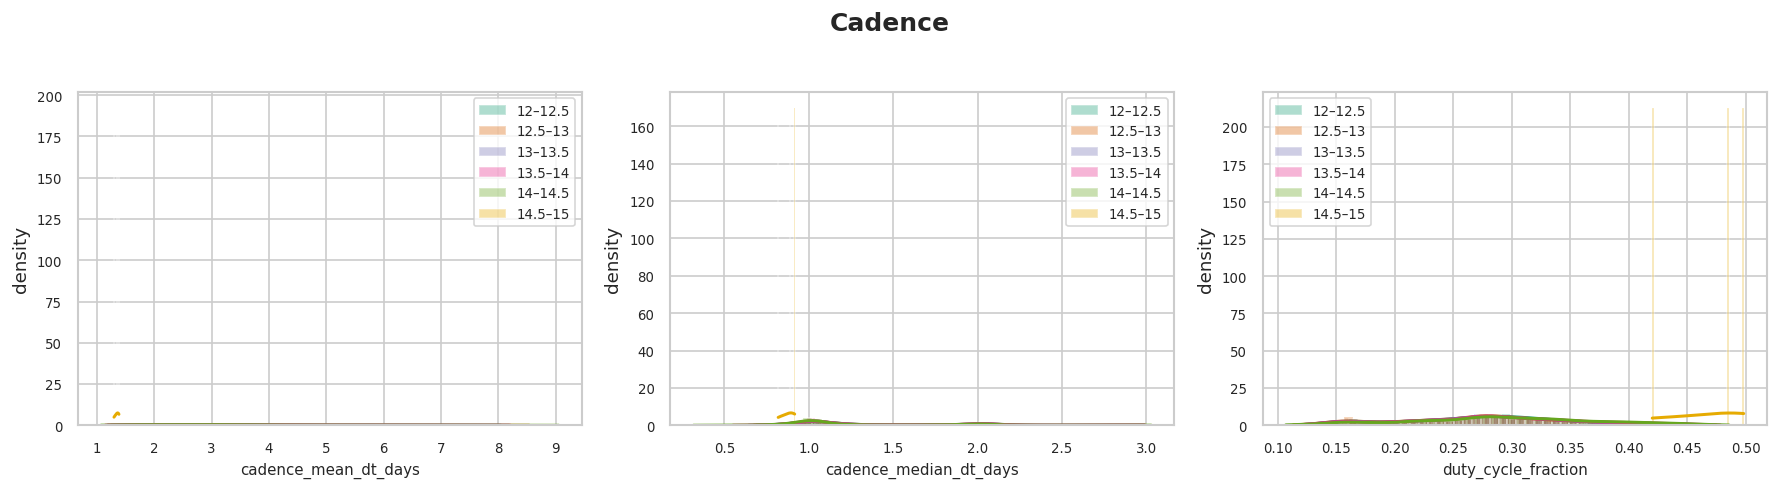

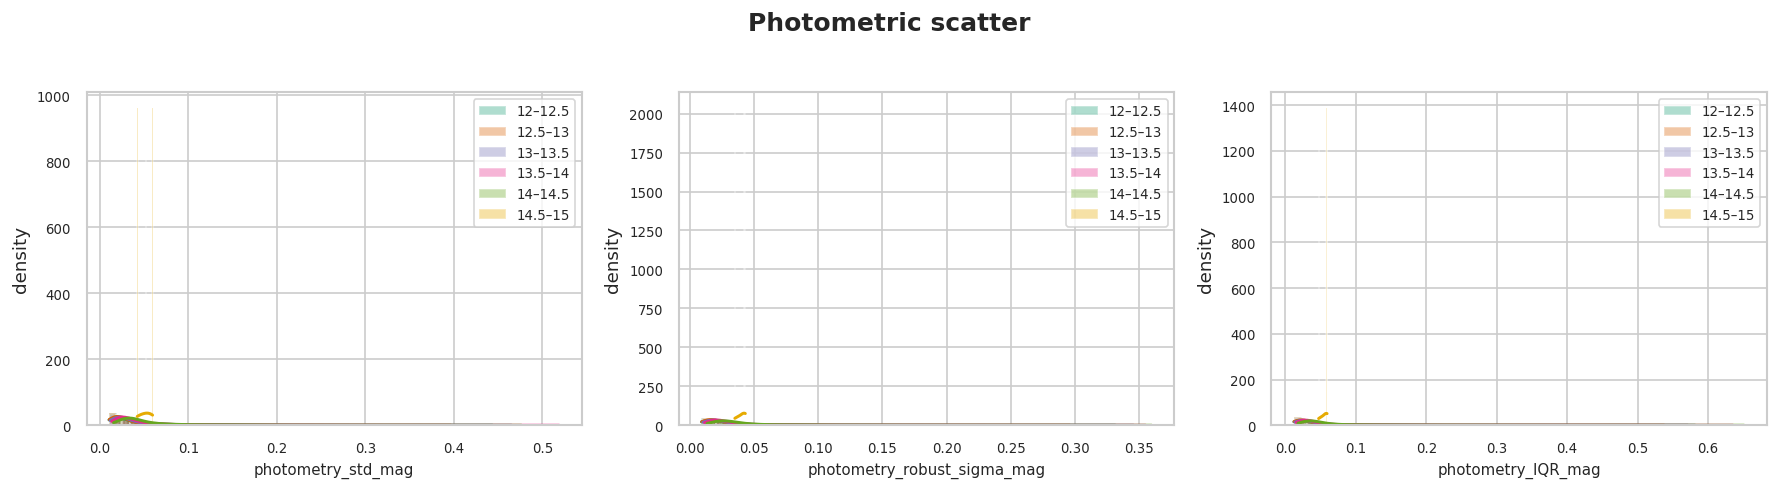

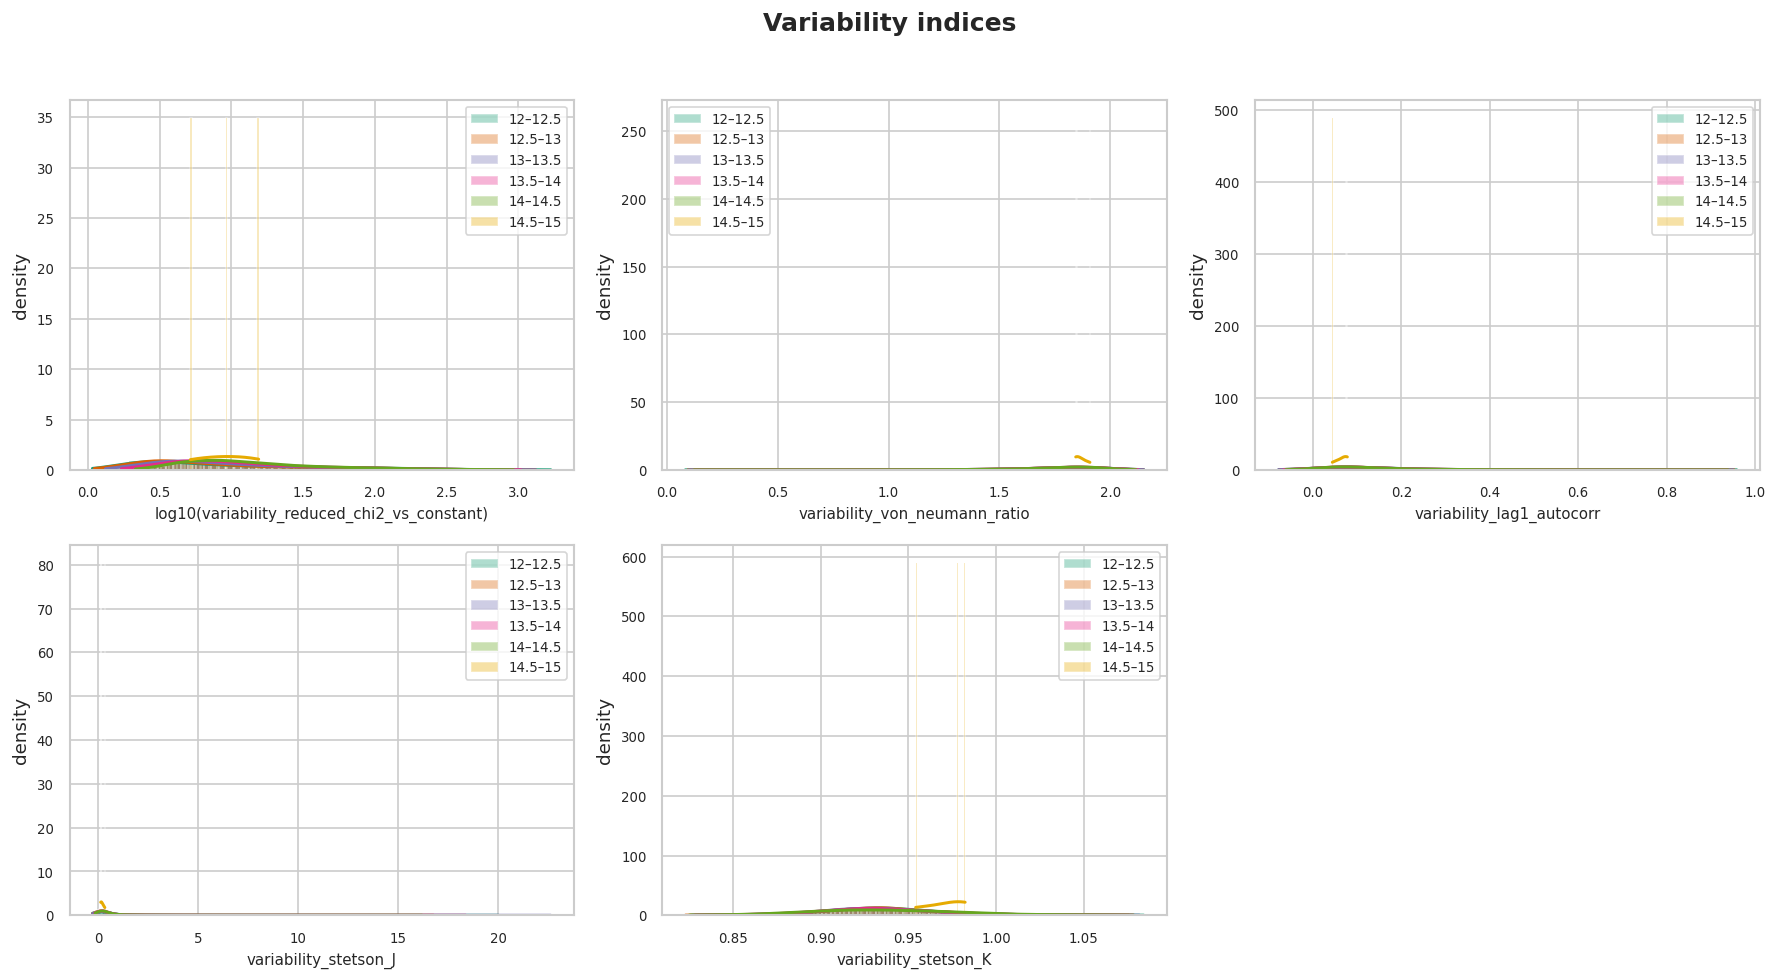

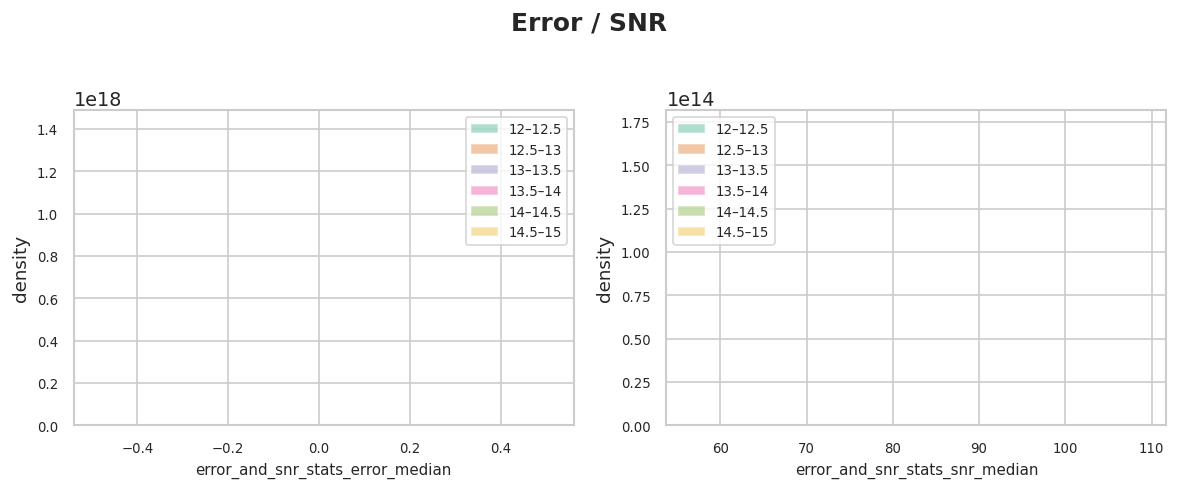

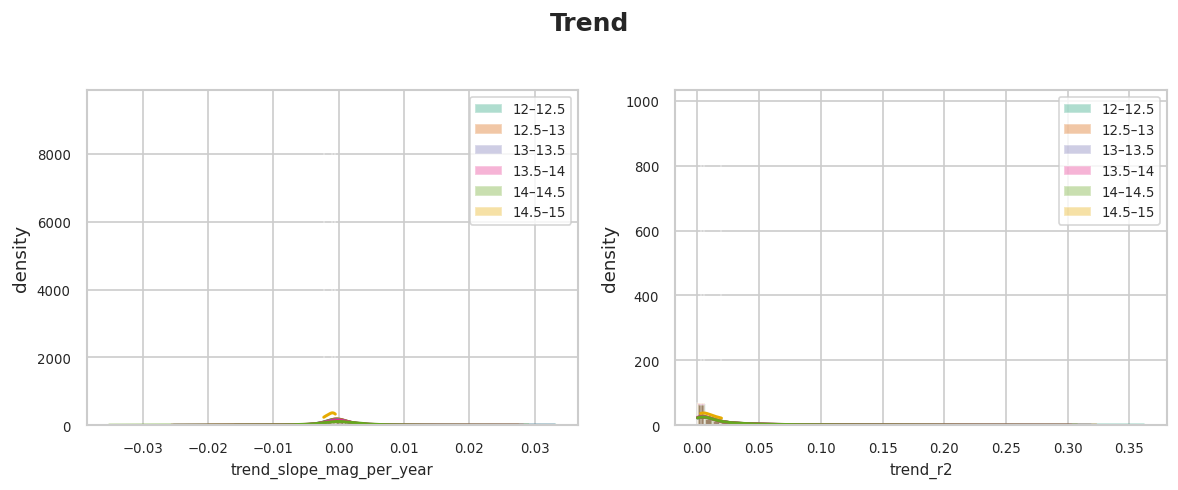

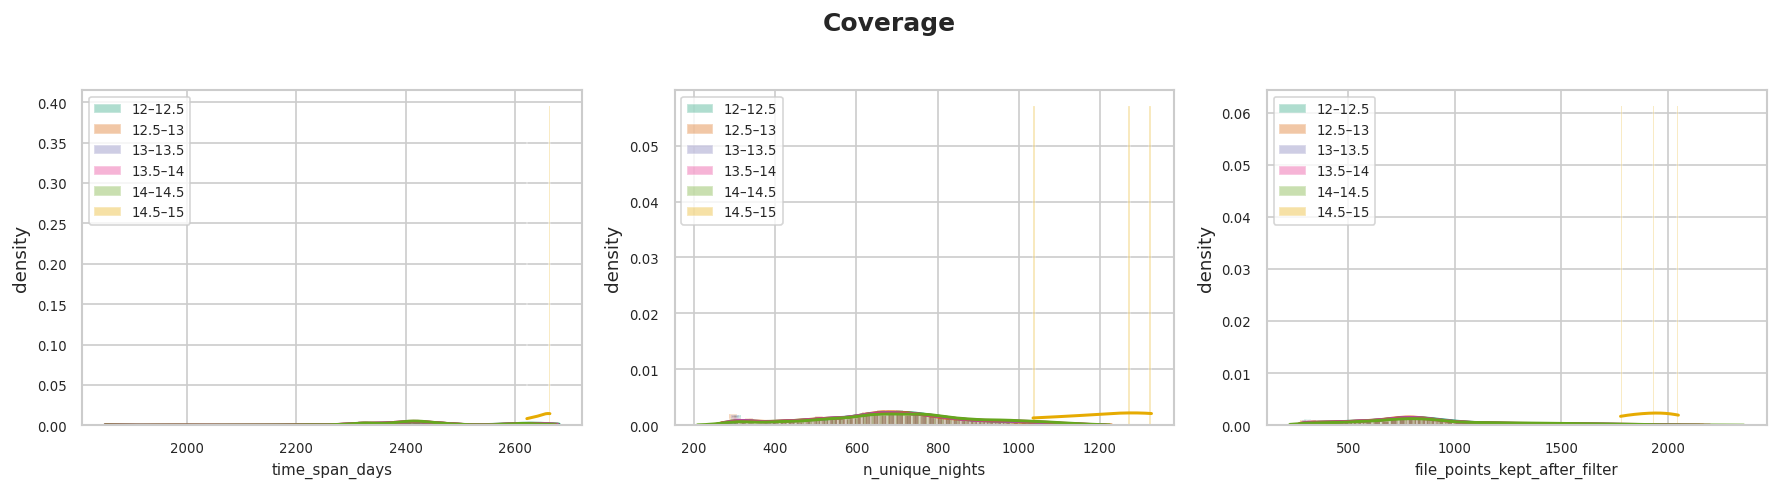

In [9]:
LOG_X = {
    'stats_variability_reduced_chi2_vs_constant',
    'stats_variability_stetson_I',
}

for group_name, cols in STAT_GROUPS.items():
    cols = [c for c in cols if c in STATS_COLS]
    if cols:
        plot_hist_group(group_name, cols, log_x_cols=LOG_X)

## \u00a75 \u2013 Correlation Heatmap
Pearson correlation of key scalar stats, per mag bin and combined.

In [10]:
KEY_STATS = [
    'stats_photometry_std_mag',
    'stats_photometry_robust_sigma_mag',
    'stats_photometry_IQR_mag',
    'stats_variability_reduced_chi2_vs_constant',
    'stats_variability_von_neumann_ratio',
    'stats_variability_lag1_autocorr',
    'stats_variability_stetson_J',
    'stats_variability_stetson_K',
    'stats_cadence_median_dt_days',
    'stats_duty_cycle_fraction',
    'stats_error_and_snr_stats_snr_median',
    'stats_trend_slope_mag_per_year',
    'stats_trend_r2',
    'stats_time_span_days',
    'stats_file_points_kept_after_filter',
]
KEY_STATS = [c for c in KEY_STATS if c in STATS_COLS]
short_labels = [c.removeprefix('stats_') for c in KEY_STATS]

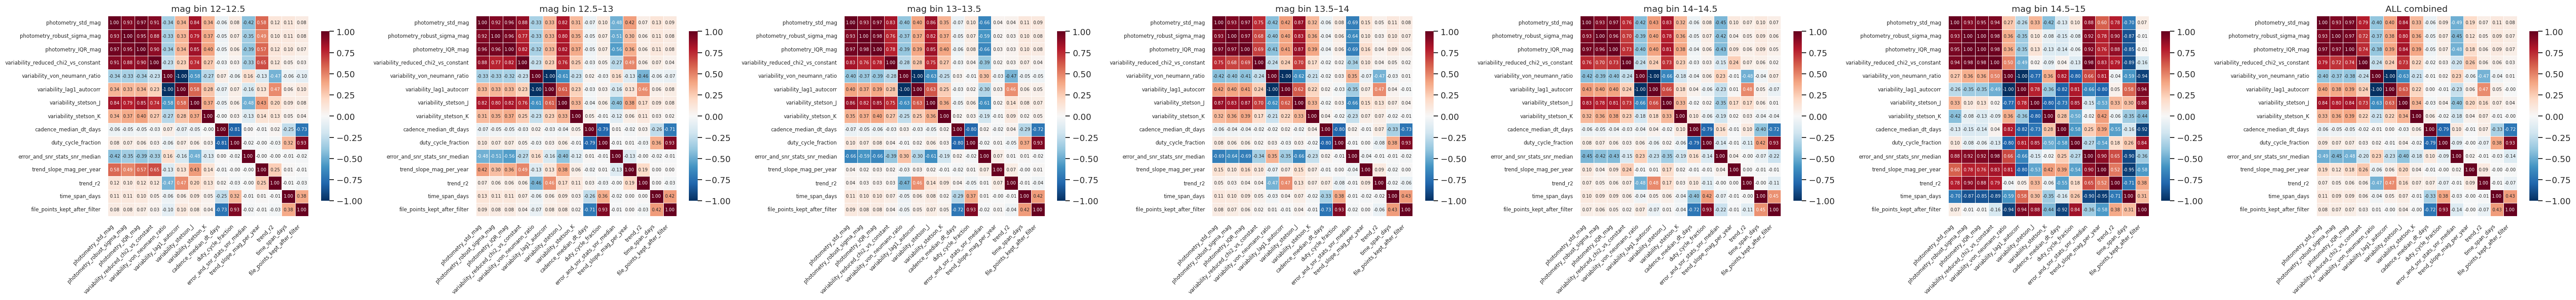

In [11]:
labels_to_plot = ordered_mag_bins(df_all['mag_bin']) + ['ALL']
n_panels = len(labels_to_plot)
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6), squeeze=False)

for i, label in enumerate(labels_to_plot):
    ax = axes[0, i]
    sub = df_all if label == 'ALL' else df_all[df_all['mag_bin'] == label]
    corr = sub[KEY_STATS].corr()
    corr.index = short_labels
    corr.columns = short_labels
    sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.3,
                cbar_kws={'shrink': 0.7},
                annot=True, fmt='.2f', annot_kws={'size': 6})
    ax.set_title(f'mag bin {label}' if label != 'ALL' else 'ALL combined',
                 fontsize=12)
    ax.tick_params(labelsize=7, rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()
plt.show()


## \u00a76 \u2013 Mag-Bin Comparison: Violin Plots
Side-by-side violin plots of key stats grouped by magnitude bin.

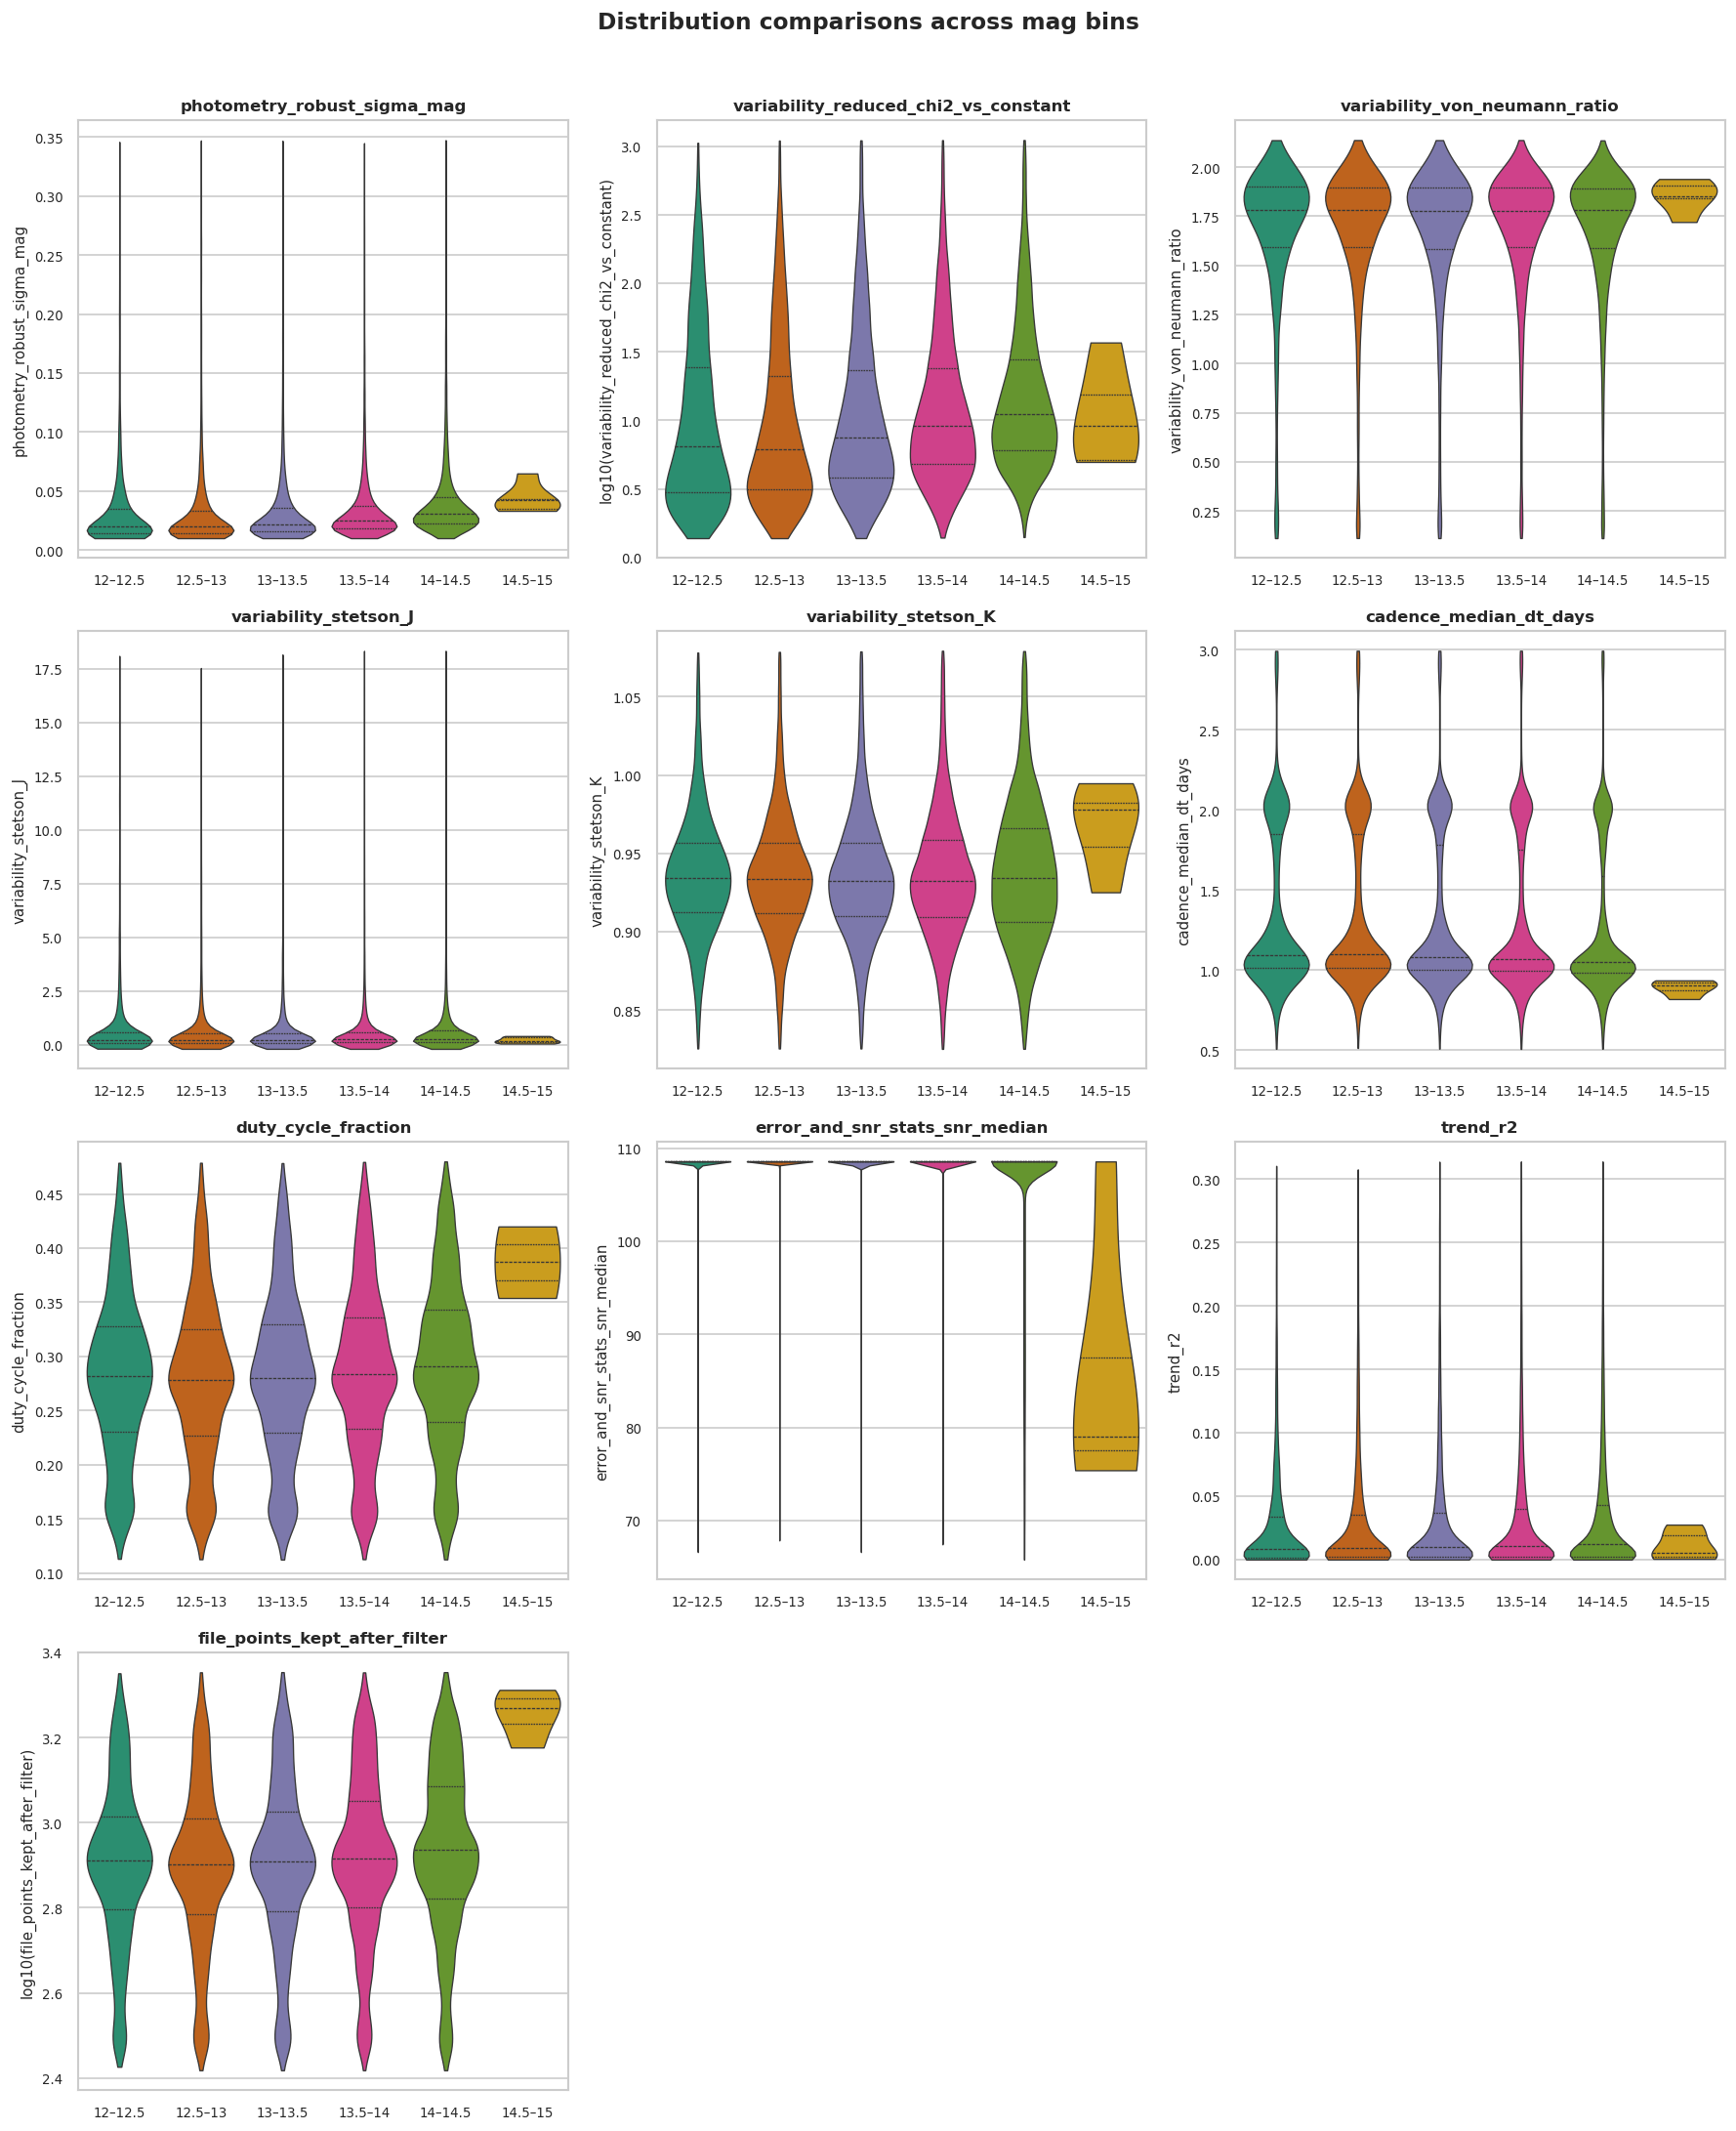

In [12]:
VIOLIN_STATS = [
    'stats_photometry_robust_sigma_mag',
    'stats_variability_reduced_chi2_vs_constant',
    'stats_variability_von_neumann_ratio',
    'stats_variability_stetson_J',
    'stats_variability_stetson_K',
    'stats_cadence_median_dt_days',
    'stats_duty_cycle_fraction',
    'stats_error_and_snr_stats_snr_median',
    'stats_trend_r2',
    'stats_file_points_kept_after_filter',
]
VIOLIN_STATS = [c for c in VIOLIN_STATS if c in STATS_COLS]

LOG_VIOLIN = {
    'stats_variability_reduced_chi2_vs_constant',
    'stats_file_points_kept_after_filter',
}

bin_order = ordered_mag_bins(df_all['mag_bin'])
palette = [BIN_PALETTE[label] for label in bin_order]

n = len(VIOLIN_STATS)
ncols_v = 3
nrows = int(np.ceil(n / ncols_v))
fig, axes = plt.subplots(nrows, ncols_v,
                         figsize=(5 * ncols_v, 4.5 * nrows), squeeze=False)

for idx, col in enumerate(VIOLIN_STATS):
    ax = axes[idx // ncols_v, idx % ncols_v]
    short = col.removeprefix('stats_')
    use_log = col in LOG_VIOLIN

    plot_df = df_all[['mag_bin', col]].dropna()
    if use_log:
        plot_df = plot_df[plot_df[col] > 0].copy()
        plot_df[col] = np.log10(plot_df[col])
        ylabel = f'log10({short})'
    else:
        ylabel = short

    lo, hi = plot_df[col].quantile([0.01, 0.99])
    plot_df = plot_df[(plot_df[col] >= lo) & (plot_df[col] <= hi)]

    sns.violinplot(data=plot_df, x='mag_bin', y=col, ax=ax,
                   palette=palette, inner='quartile', linewidth=0.8,
                   order=bin_order, cut=0, density_norm='width')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlabel('')
    ax.set_title(short, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)

for idx in range(n, nrows * ncols_v):
    axes[idx // ncols_v, idx % ncols_v].set_visible(False)

fig.suptitle('Distribution comparisons across mag bins',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


## \u00a78 \u2013 Scatter Plots
Pairwise scatter plots of key statistics, colored by magnitude bin.
Points are drawn with transparency to reveal density structure.

In [13]:
def scatter_grid(pairs, title, log_axes=None, figsize_per=4.5):
    """Draw a grid of scatter plots, one per (x, y) pair."""
    log_axes = log_axes or {}
    n = len(pairs)
    ncols_s = min(n, 3)
    nrows = int(np.ceil(n / ncols_s))
    fig, axes = plt.subplots(nrows, ncols_s,
                             figsize=(figsize_per * ncols_s, figsize_per * nrows),
                             squeeze=False)
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)

    for idx, (xcol, ycol) in enumerate(pairs):
        ax = axes[idx // ncols_s, idx % ncols_s]
        for label, color in BIN_PALETTE.items():
            mask = df_all['mag_bin'] == label
            x = df_all.loc[mask, xcol].values.copy()
            y = df_all.loc[mask, ycol].values.copy()
            valid = np.isfinite(x) & np.isfinite(y)
            if xcol in log_axes:
                valid &= (x > 0)
            if ycol in log_axes:
                valid &= (y > 0)
            x, y = x[valid], y[valid]
            if xcol in log_axes:
                x = np.log10(x)
            if ycol in log_axes:
                y = np.log10(y)
            ax.scatter(x, y, s=6, alpha=0.25, color=color, label=label,
                       edgecolors='none', rasterized=True)

        xshort = xcol.removeprefix('stats_')
        yshort = ycol.removeprefix('stats_')
        if xcol in log_axes:
            xshort = f'log10({xshort})'
        if ycol in log_axes:
            yshort = f'log10({yshort})'
        ax.set_xlabel(xshort, fontsize=8)
        ax.set_ylabel(yshort, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, markerscale=3)

    for idx in range(n, nrows * ncols_s):
        axes[idx // ncols_s, idx % ncols_s].set_visible(False)
    fig.tight_layout()
    plt.show()

### 8a \u2013 Variability Diagnostics
Scatter plots pairing the core variability indices against each other.

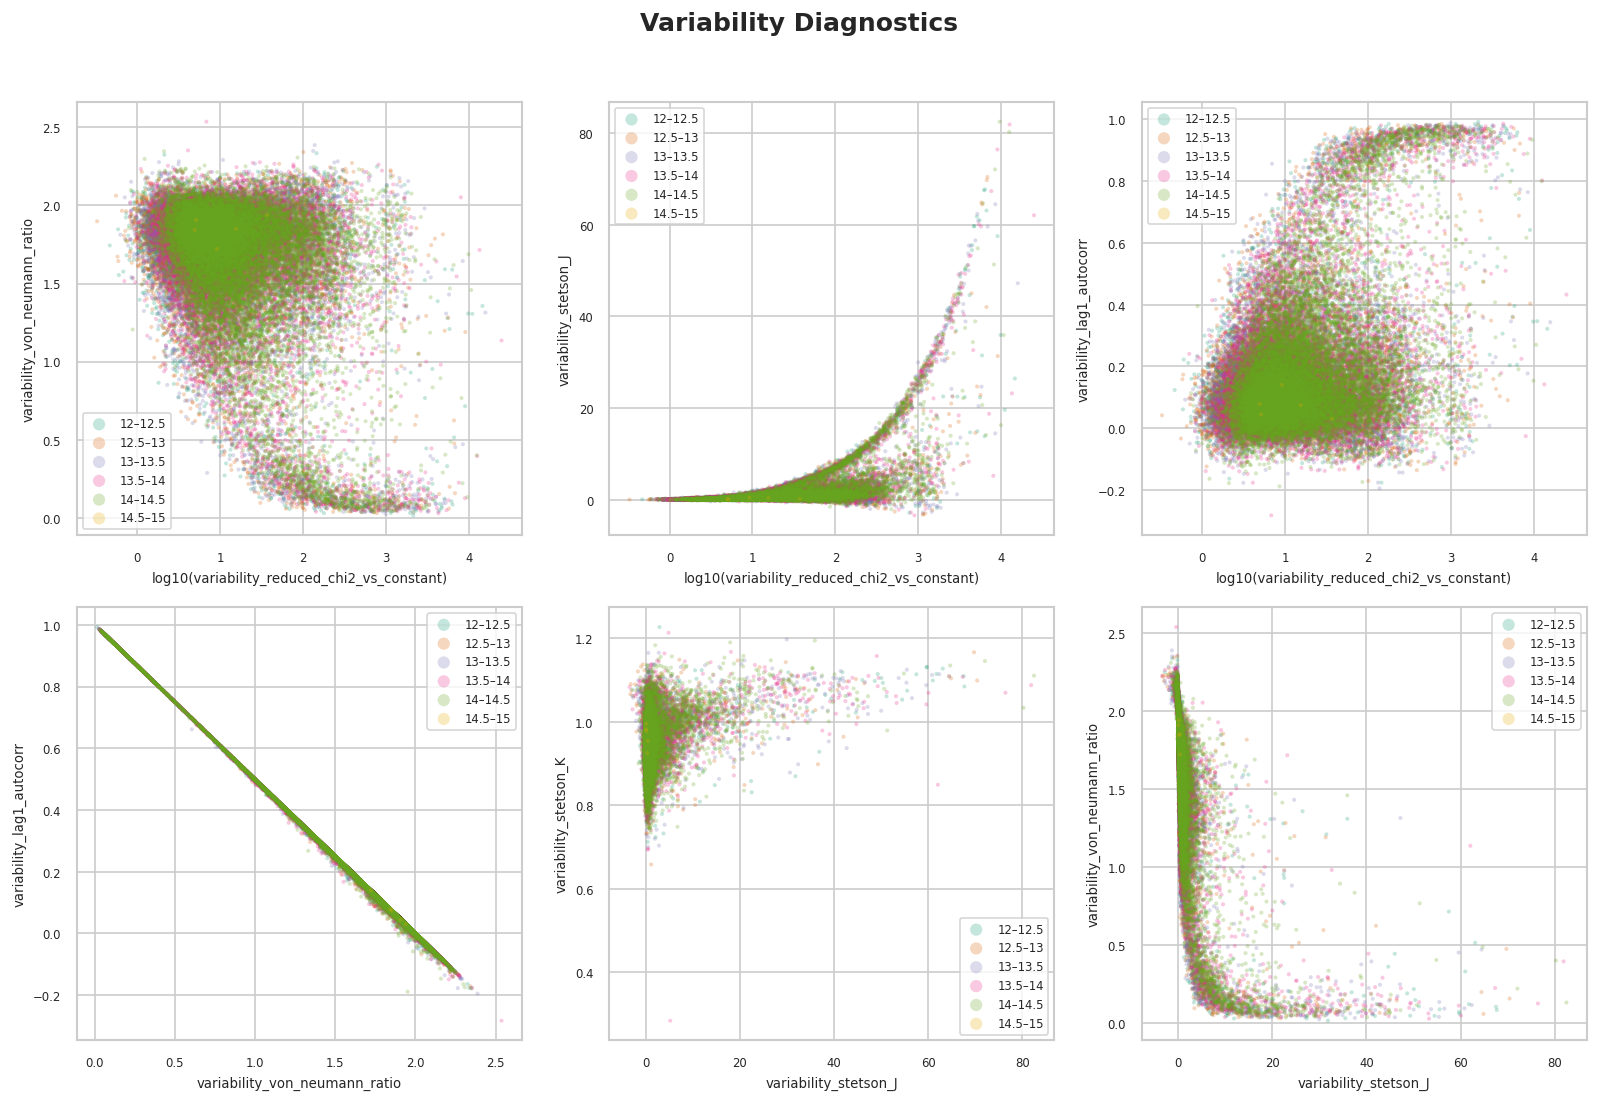

In [14]:
scatter_grid([
    ('stats_variability_reduced_chi2_vs_constant', 'stats_variability_von_neumann_ratio'),
    ('stats_variability_reduced_chi2_vs_constant', 'stats_variability_stetson_J'),
    ('stats_variability_reduced_chi2_vs_constant', 'stats_variability_lag1_autocorr'),
    ('stats_variability_von_neumann_ratio',        'stats_variability_lag1_autocorr'),
    ('stats_variability_stetson_J',                'stats_variability_stetson_K'),
    ('stats_variability_stetson_J',                'stats_variability_von_neumann_ratio'),
], title='Variability Diagnostics',
   log_axes={'stats_variability_reduced_chi2_vs_constant'})

### 8b \u2013 Photometric Scatter vs Variability
How photometric dispersion relates to variability metrics.

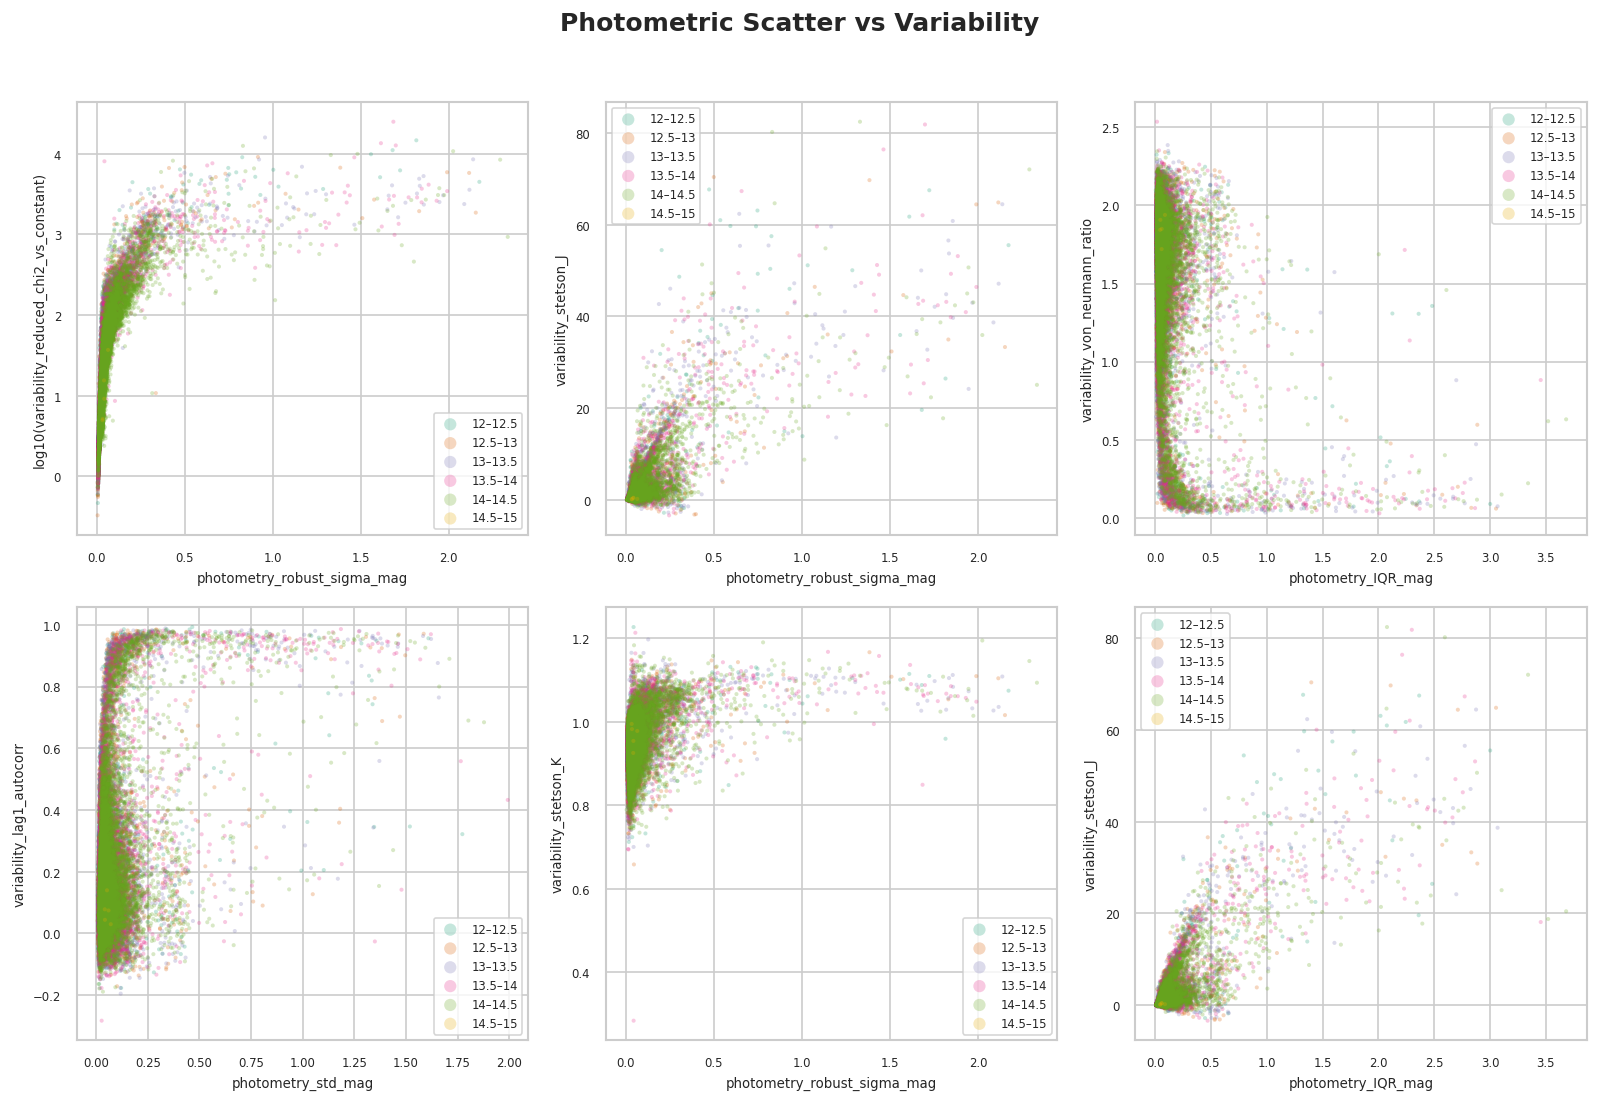

In [15]:
scatter_grid([
    ('stats_photometry_robust_sigma_mag', 'stats_variability_reduced_chi2_vs_constant'),
    ('stats_photometry_robust_sigma_mag', 'stats_variability_stetson_J'),
    ('stats_photometry_IQR_mag',          'stats_variability_von_neumann_ratio'),
    ('stats_photometry_std_mag',          'stats_variability_lag1_autocorr'),
    ('stats_photometry_robust_sigma_mag', 'stats_variability_stetson_K'),
    ('stats_photometry_IQR_mag',          'stats_variability_stetson_J'),
], title='Photometric Scatter vs Variability',
   log_axes={'stats_variability_reduced_chi2_vs_constant'})

### 8c \u2013 Cadence & Coverage vs Variability
Whether cadence or coverage properties bias the variability diagnostics.

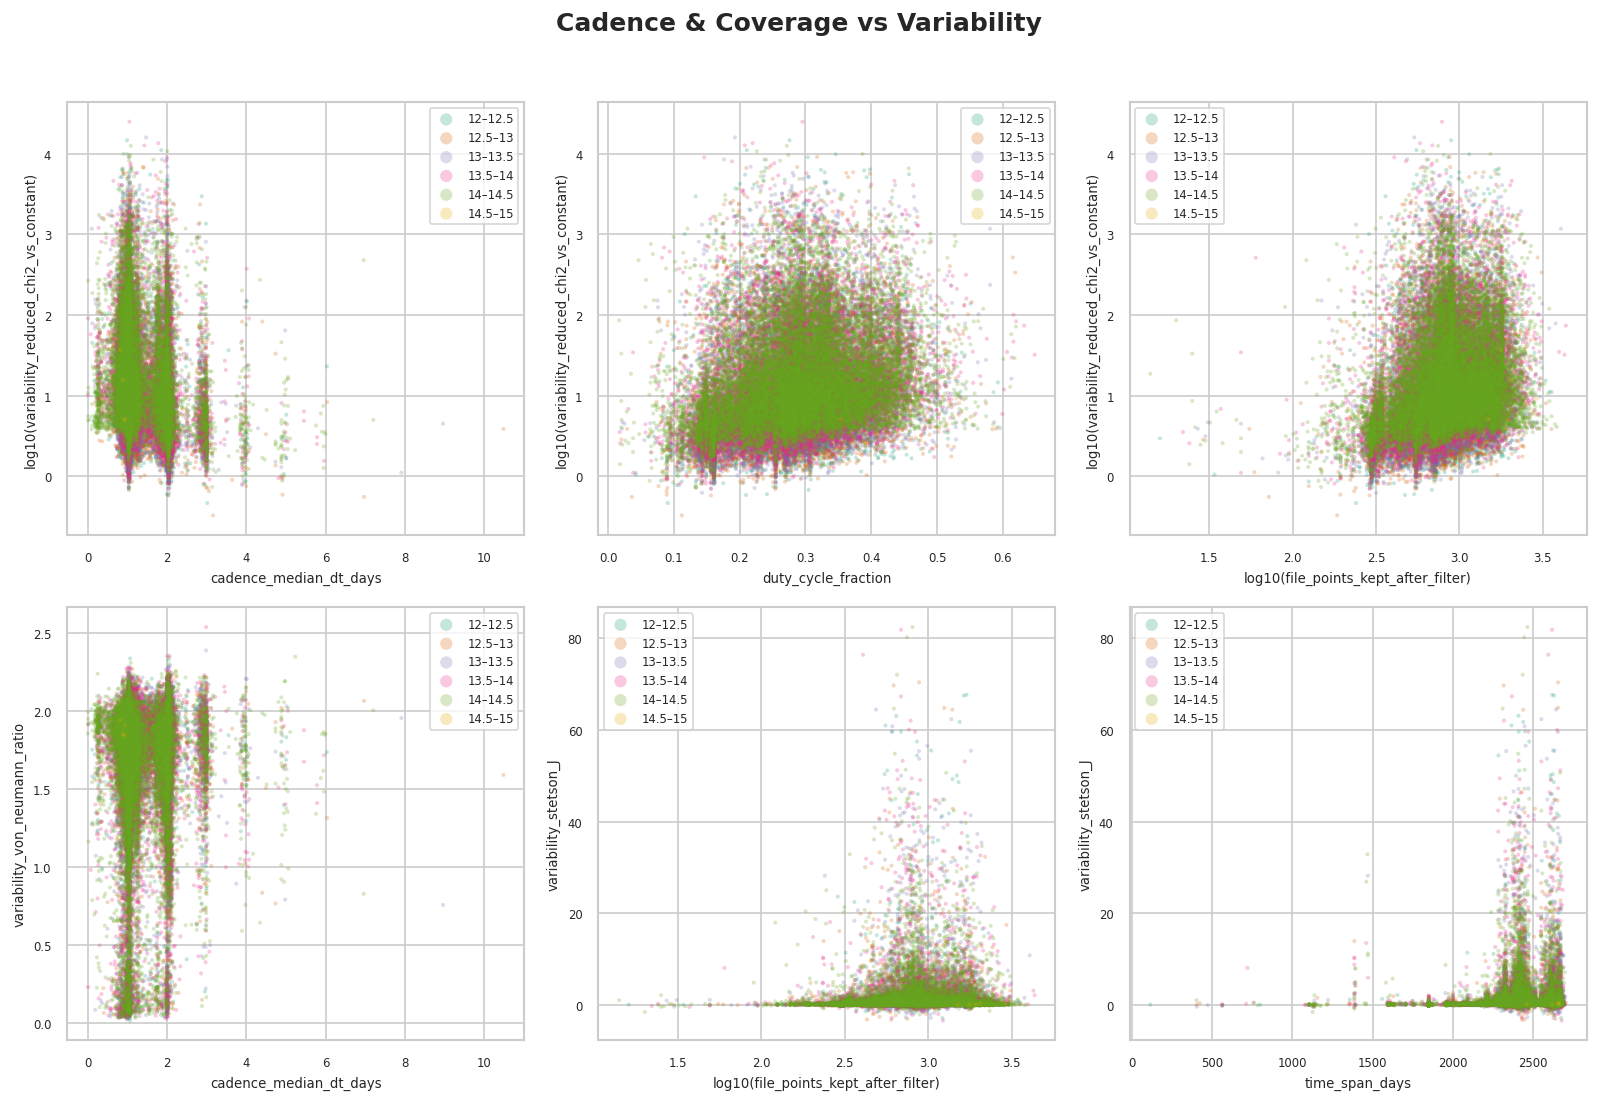

In [16]:
scatter_grid([
    ('stats_cadence_median_dt_days',         'stats_variability_reduced_chi2_vs_constant'),
    ('stats_duty_cycle_fraction',            'stats_variability_reduced_chi2_vs_constant'),
    ('stats_file_points_kept_after_filter',  'stats_variability_reduced_chi2_vs_constant'),
    ('stats_cadence_median_dt_days',         'stats_variability_von_neumann_ratio'),
    ('stats_file_points_kept_after_filter',  'stats_variability_stetson_J'),
    ('stats_time_span_days',                 'stats_variability_stetson_J'),
], title='Cadence & Coverage vs Variability',
   log_axes={'stats_variability_reduced_chi2_vs_constant',
             'stats_file_points_kept_after_filter'})

### 8d \u2013 Error / SNR vs Photometric Properties
How photometric errors and signal-to-noise relate to scatter and variability.

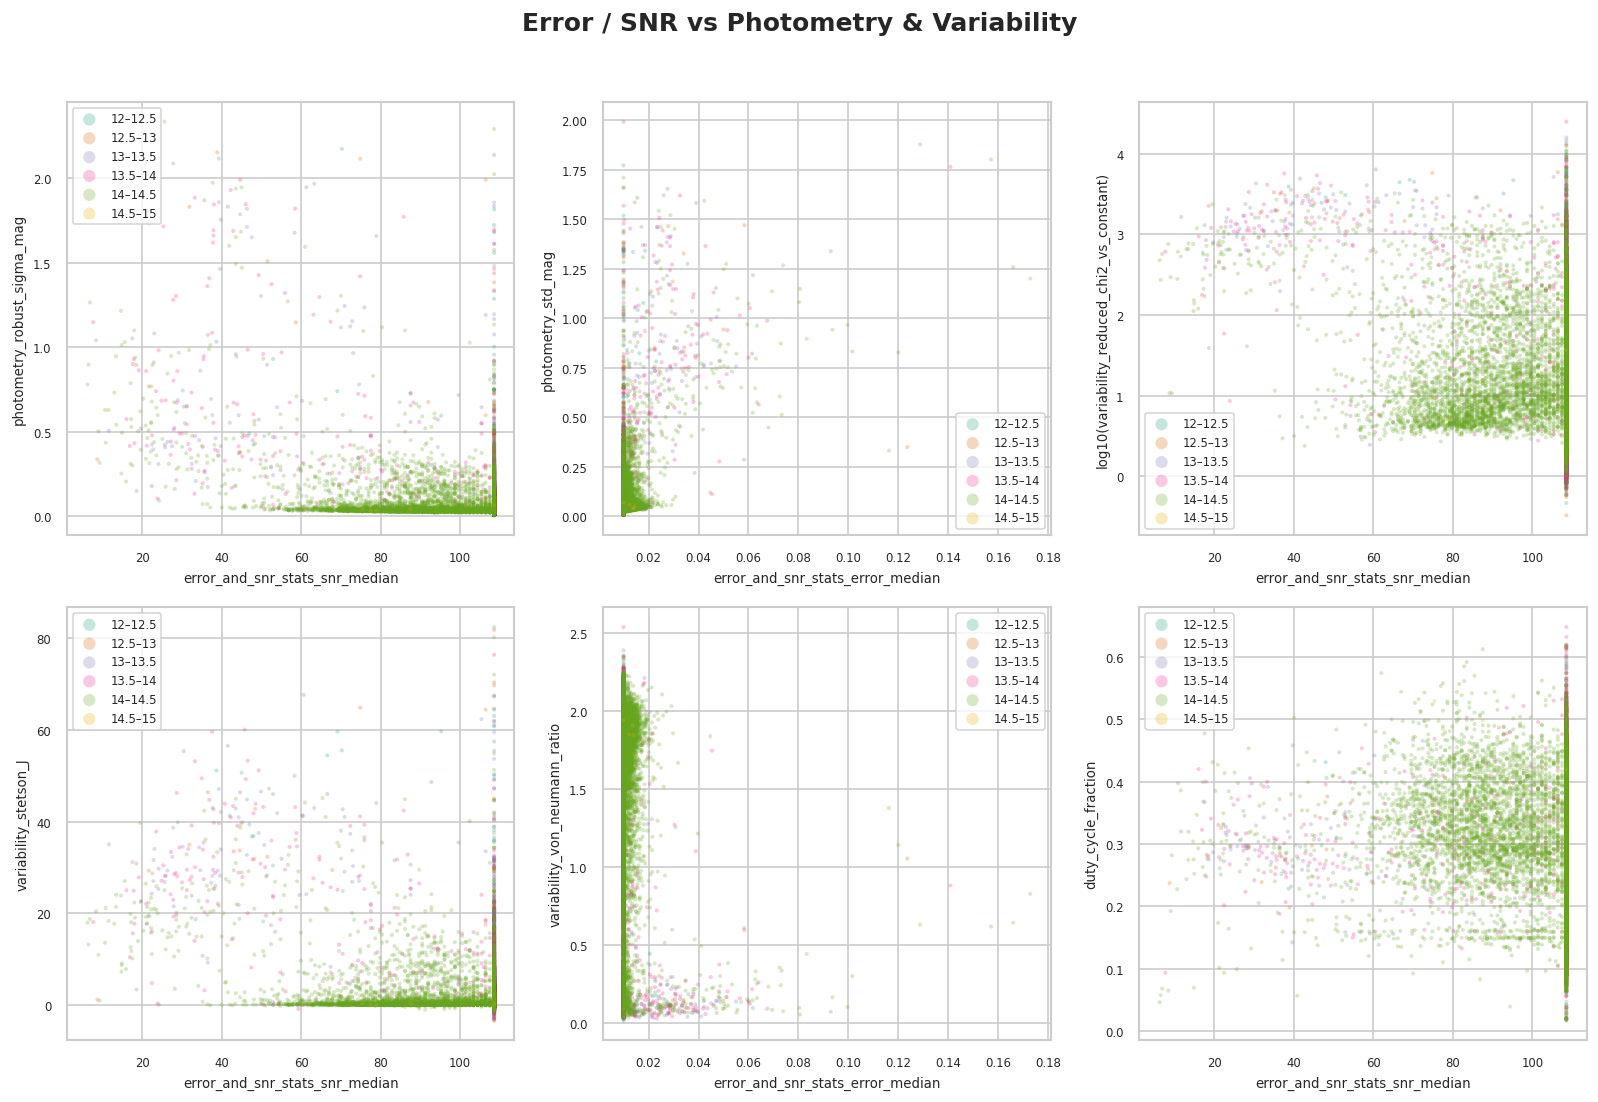

In [17]:
scatter_grid([
    ('stats_error_and_snr_stats_snr_median',   'stats_photometry_robust_sigma_mag'),
    ('stats_error_and_snr_stats_error_median', 'stats_photometry_std_mag'),
    ('stats_error_and_snr_stats_snr_median',   'stats_variability_reduced_chi2_vs_constant'),
    ('stats_error_and_snr_stats_snr_median',   'stats_variability_stetson_J'),
    ('stats_error_and_snr_stats_error_median', 'stats_variability_von_neumann_ratio'),
    ('stats_error_and_snr_stats_snr_median',   'stats_duty_cycle_fraction'),
], title='Error / SNR vs Photometry & Variability',
   log_axes={'stats_variability_reduced_chi2_vs_constant'})

### 8e \u2013 Trend vs Other Diagnostics
Linear trend properties compared to scatter, variability, and coverage.

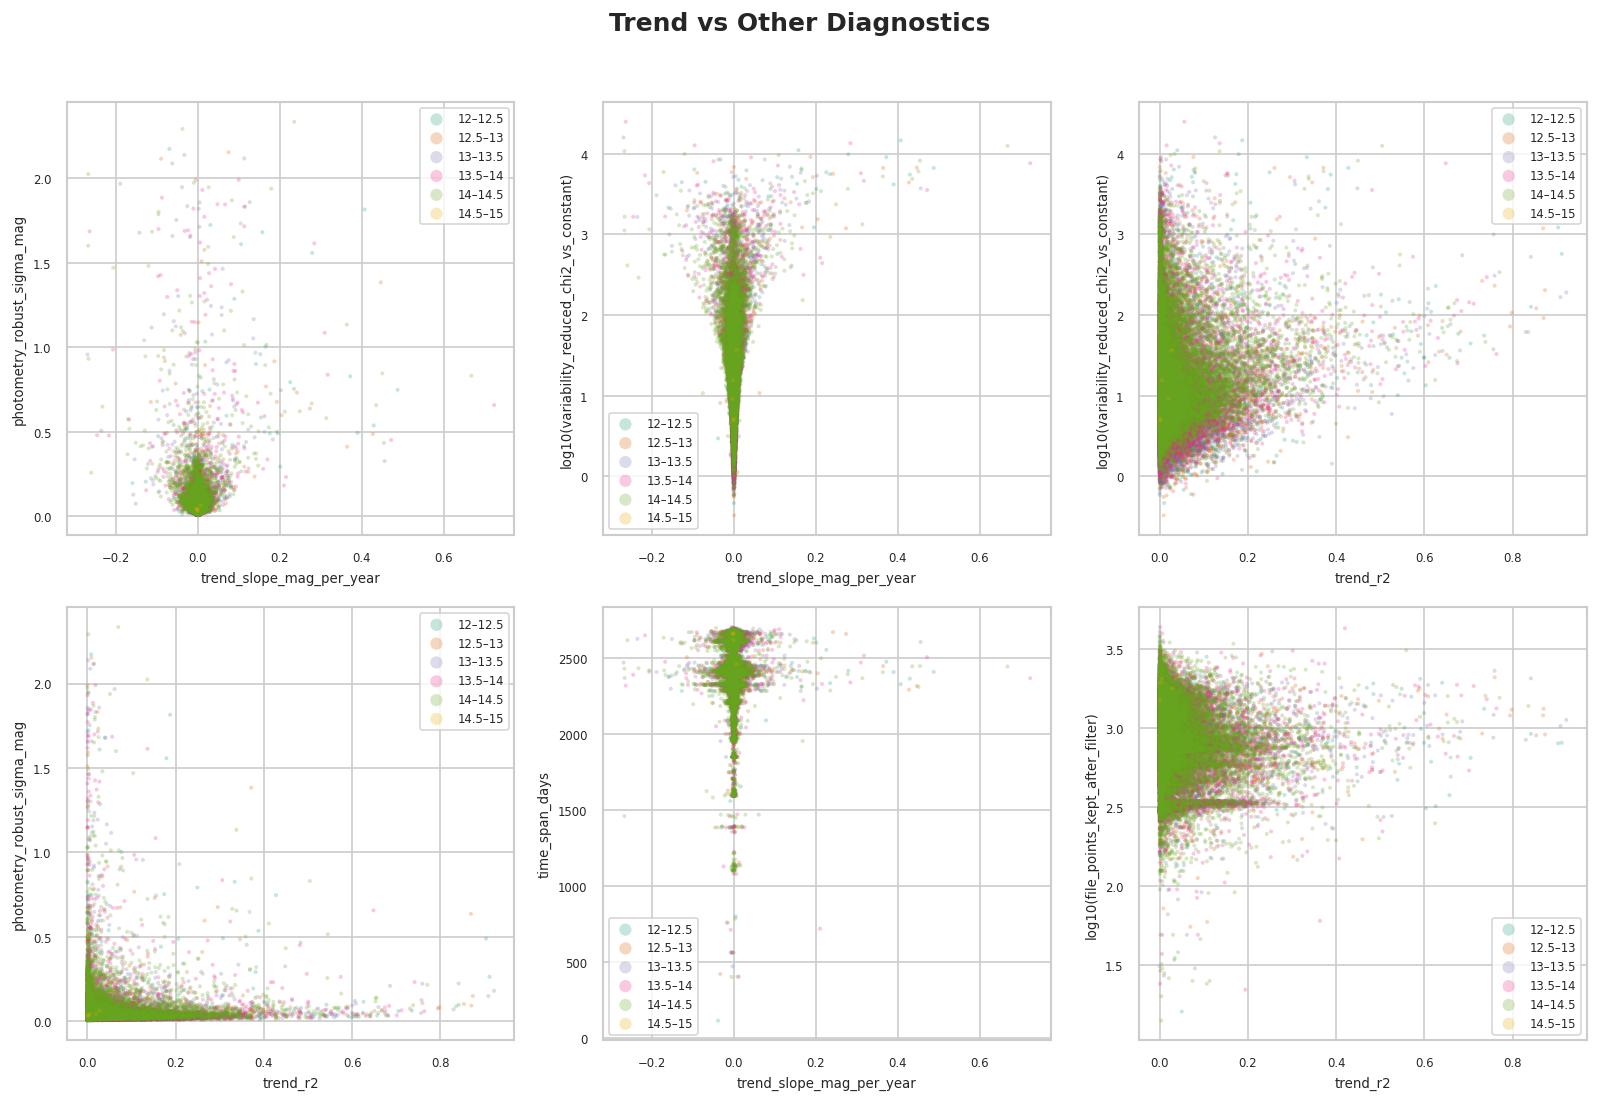

In [18]:
scatter_grid([
    ('stats_trend_slope_mag_per_year', 'stats_photometry_robust_sigma_mag'),
    ('stats_trend_slope_mag_per_year', 'stats_variability_reduced_chi2_vs_constant'),
    ('stats_trend_r2',                 'stats_variability_reduced_chi2_vs_constant'),
    ('stats_trend_r2',                 'stats_photometry_robust_sigma_mag'),
    ('stats_trend_slope_mag_per_year', 'stats_time_span_days'),
    ('stats_trend_r2',                 'stats_file_points_kept_after_filter'),
], title='Trend vs Other Diagnostics',
   log_axes={'stats_variability_reduced_chi2_vs_constant',
             'stats_file_points_kept_after_filter'})

### 8f \u2013 Compact Pair Plot (top variability stats)
Seaborn pairplot of 5 key variability/photometry stats for a compact overview.

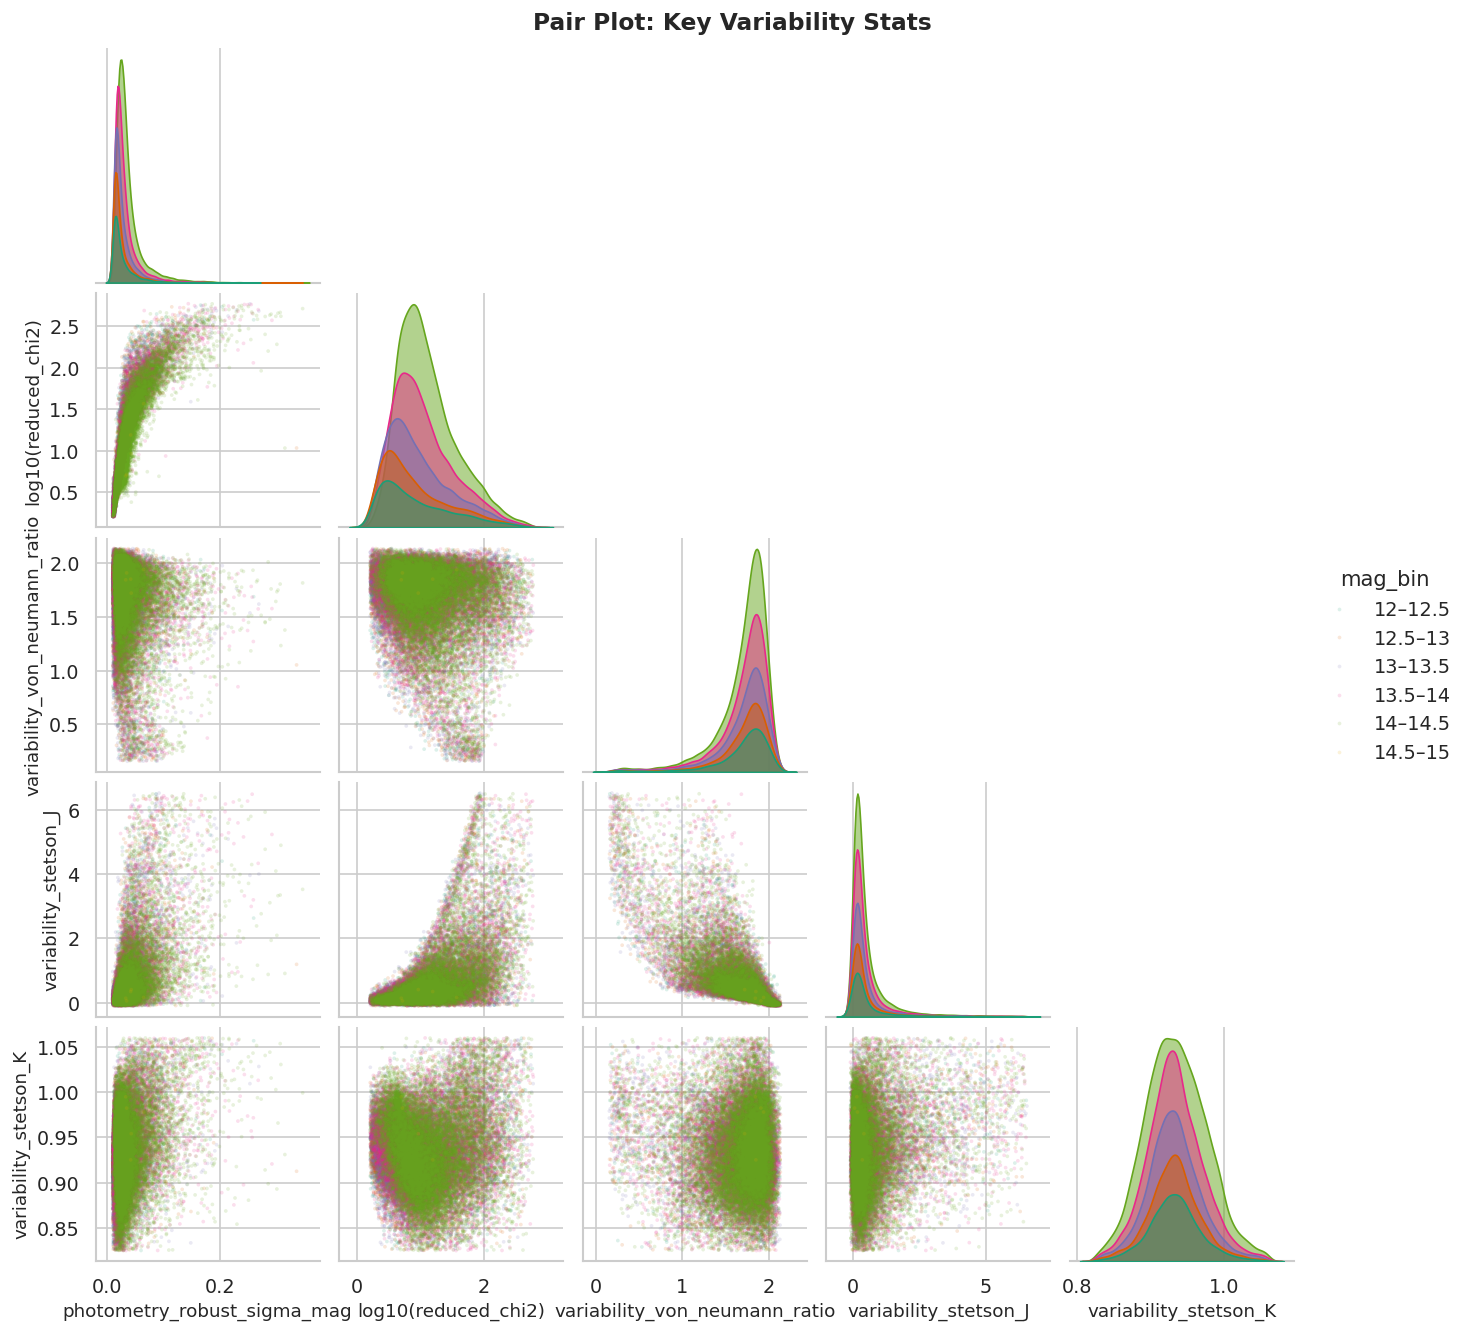

In [19]:
PAIR_COLS = [
    'stats_photometry_robust_sigma_mag',
    'stats_variability_reduced_chi2_vs_constant',
    'stats_variability_von_neumann_ratio',
    'stats_variability_stetson_J',
    'stats_variability_stetson_K',
]
PAIR_COLS = [c for c in PAIR_COLS if c in STATS_COLS]

pair_df = df_all[['mag_bin'] + PAIR_COLS].dropna().copy()
# log-transform chi2 for readability
chi2_col = 'stats_variability_reduced_chi2_vs_constant'
if chi2_col in pair_df.columns:
    pair_df = pair_df[pair_df[chi2_col] > 0].copy()
    pair_df[chi2_col] = np.log10(pair_df[chi2_col])

# clip to 1st-99th pctl per column
for c in PAIR_COLS:
    lo, hi = pair_df[c].quantile([0.01, 0.99])
    pair_df = pair_df[(pair_df[c] >= lo) & (pair_df[c] <= hi)]

short_rename = {c: c.removeprefix('stats_') for c in PAIR_COLS}
if chi2_col in short_rename:
    short_rename[chi2_col] = 'log10(reduced_chi2)'
pair_df = pair_df.rename(columns=short_rename)

present_labels = ordered_mag_bins(pair_df['mag_bin'])
pair_palette = {label: BIN_PALETTE[label] for label in present_labels}
g = sns.pairplot(pair_df, hue='mag_bin', hue_order=present_labels, palette=pair_palette,
                 plot_kws={'s': 5, 'alpha': 0.15, 'edgecolor': 'none',
                           'rasterized': True},
                 diag_kws={'alpha': 0.5},
                 height=2.2, aspect=1.0,
                 corner=True)
g.figure.suptitle('Pair Plot: Key Variability Stats', y=1.01,
                  fontsize=14, fontweight='bold')
plt.show()


## \u00a79 \u2013 Outlier Flagging
Candidates whose variability stats fall **>3 MAD** from the per-mag-bin median.

In [20]:
OUTLIER_COLS = [
    'stats_variability_reduced_chi2_vs_constant',
    'stats_variability_von_neumann_ratio',
    'stats_variability_lag1_autocorr',
    'stats_variability_stetson_J',
    'stats_variability_stetson_K',
    'stats_photometry_robust_sigma_mag',
    'stats_trend_slope_mag_per_year',
]
OUTLIER_COLS = [c for c in OUTLIER_COLS if c in STATS_COLS]

outlier_flags = pd.DataFrame(index=df_all.index)

for col in OUTLIER_COLS:
    med = df_all.groupby('mag_bin')[col].transform('median')
    mad = df_all.groupby('mag_bin')[col].transform(
        lambda s: np.median(np.abs(s - s.median())))
    mad = mad.replace(0, np.nan)
    deviation = np.abs(df_all[col] - med) / (1.4826 * mad)
    outlier_flags[col] = deviation > 3.0

df_all['n_outlier_stats'] = outlier_flags.sum(axis=1)
df_outliers = df_all[df_all['n_outlier_stats'] >= 2].copy()

display_cols = ['mag_bin', 'path', 'n_outlier_stats'] + OUTLIER_COLS
print(f'Candidates flagged as outlier on >=2 stats: '
      f'{len(df_outliers):,} / {len(df_all):,}')
df_outliers[display_cols].sort_values(
    'n_outlier_stats', ascending=False).head(30)

Candidates flagged as outlier on >=2 stats: 2,360 / 48,831


,mag_bin,path,n_outlier_stats,stats_variability_reduced_chi2_vs_constant,stats_variability_von_neumann_ratio,stats_variability_lag1_autocorr,stats_variability_stetson_J,stats_variability_stetson_K,stats_photometry_robust_sigma_mag,stats_trend_slope_mag_per_year
1700,12–12.5,/data/poohbah/1/assassin/rowan.90/lcsv2/12_12....,7,5093.055734,0.120338,0.939778,61.761261,1.114529,1.609805,0.105448
4347,12.5–13,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,7,50.969261,0.194153,0.902918,5.465645,1.049850,0.081930,0.020166
6630,12.5–13,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,7,230.998651,0.036895,0.981535,12.808162,1.071231,0.108657,0.071364
1091,12–12.5,/data/poohbah/1/assassin/rowan.90/lcsv2/12_12....,7,1217.866712,0.102535,0.948506,30.281140,1.118251,0.490222,0.194838
4387,12.5–13,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,7,2688.431632,0.078380,0.960787,44.642308,1.102094,1.575774,0.015947
1102,12–12.5,/data/poohbah/1/assassin/rowan.90/lcsv2/12_12....,7,2289.596146,0.055251,0.972366,41.246953,1.102920,0.749362,0.028324
4380,12.5–13,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,7,690.536612,0.132066,0.933913,20.029789,1.039291,0.296299,-0.026923
6698,12.5–13,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,7,99.401595,0.062416,0.968782,8.283245,1.063184,0.053363,-0.034338
6702,12.5–13,/data/poohbah/1/assassin/rowan.90/lcsv2/12.5_1...,7,1622.205996,0.083319,0.958315,33.691101,1.081142,0.380824,0.011695
1154,12–12.5,/data/poohbah/1/assassin/rowan.90/lcsv2/12_12....,7,156.668458,0.066007,0.966949,10.770653,1.102974,0.099202,-0.052469


In [21]:
# ── outlier count per mag bin ─────────────────────────────────────
outlier_summary = (
    df_all.groupby('mag_bin')['n_outlier_stats']
    .agg(total='size',
         outliers_ge2=lambda s: (s >= 2).sum(),
         outliers_ge3=lambda s: (s >= 3).sum())
)
outlier_summary['pct_ge2'] = (
    100 * outlier_summary['outliers_ge2'] / outlier_summary['total']).round(1)
outlier_summary['pct_ge3'] = (
    100 * outlier_summary['outliers_ge3'] / outlier_summary['total']).round(1)
outlier_summary

,total,outliers_ge2,outliers_ge3,pct_ge2,pct_ge3
mag_bin,,,,,
12.5–13,6074,1405,985,23.1,16.2
12–12.5,4069,954,666,23.4,16.4
13.5–14,12506,0,0,0.0,0.0
13–13.5,9014,0,0,0.0,0.0
14.5–15,5,1,0,20.0,0.0
14–14.5,17163,0,0,0.0,0.0
